In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [25]:
tabular_full = pd.read_csv("data/processed/train_tabular.csv")
tabular_full["id"] = tabular_full["id"].astype(str)

print(tabular_full.shape)
print(tabular_full.columns)


(16209, 20)
Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'log_price'],
      dtype='object')


In [26]:
# Build embedding dataframe
emb_df = pd.DataFrame(train_img_embeddings)
emb_df["id"] = train_img_ids
emb_df["id"] = emb_df["id"].astype(str)

print(emb_df.shape)
print(emb_df["id"].nunique())


(16101, 513)
16101


In [27]:
import numpy as np
import pandas as pd

# Load saved embeddings
train_img_embeddings = np.load("data/processed/train_image_embeddings.npy")
train_img_ids = np.load("data/processed/train_image_ids.npy")

print(train_img_embeddings.shape)
print(len(train_img_ids))


(16101, 512)
16101


In [28]:
emb_df = pd.DataFrame(train_img_embeddings)
emb_df["id"] = train_img_ids.astype(str)

print(emb_df.shape)
print(emb_df["id"].nunique())


(16101, 513)
16101


In [29]:
multimodal_df = tabular_full.merge(
    emb_df,
    on="id",
    how="inner"
)

print("Merged shape:", multimodal_df.shape)
print("Unique merged IDs:", multimodal_df["id"].nunique())


Merged shape: (16200, 532)
Unique merged IDs: 16101


In [30]:
# Check duplicates
dup_counts = multimodal_df["id"].value_counts()
print("IDs with duplicates:", (dup_counts > 1).sum())

# Deduplicate: keep first occurrence per id
multimodal_df = multimodal_df.drop_duplicates(subset="id", keep="first")

print("After dedup:")
print("Shape:", multimodal_df.shape)
print("Unique IDs:", multimodal_df["id"].nunique())


IDs with duplicates: 99
After dedup:
Shape: (16101, 532)
Unique IDs: 16101


In [31]:
y = multimodal_df["log_price"]
X = multimodal_df.drop(columns=["log_price", "id"])

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_val.shape


((12880, 530), (3221, 530))

In [34]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Scale features for neural network
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    max_iter=200,
    random_state=42,
    verbose=True
)

mlp.fit(X_train_scaled, y_train)


Iteration 1, loss = 11.99961113
Iteration 2, loss = 0.68595654
Iteration 3, loss = 0.48223342
Iteration 4, loss = 0.37158833
Iteration 5, loss = 0.29073348
Iteration 6, loss = 0.23983653
Iteration 7, loss = 0.19837957
Iteration 8, loss = 0.16445422
Iteration 9, loss = 0.13719963
Iteration 10, loss = 0.11845530
Iteration 11, loss = 0.10002889
Iteration 12, loss = 0.08323195
Iteration 13, loss = 0.07204592
Iteration 14, loss = 0.06217301
Iteration 15, loss = 0.05386055
Iteration 16, loss = 0.04919403
Iteration 17, loss = 0.04224759
Iteration 18, loss = 0.03736729
Iteration 19, loss = 0.03178881
Iteration 20, loss = 0.02911883
Iteration 21, loss = 0.02423870
Iteration 22, loss = 0.02233158
Iteration 23, loss = 0.01981490
Iteration 24, loss = 0.01769557
Iteration 25, loss = 0.01494641
Iteration 26, loss = 0.01349312
Iteration 27, loss = 0.01187963
Iteration 28, loss = 0.01143020
Iteration 29, loss = 0.01190354
Iteration 30, loss = 0.01042704
Iteration 31, loss = 0.00880915
Iteration 32, lo

,loss,'squared_error'
,hidden_layer_sizes,"(256, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True


In [35]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_val_pred = mlp.predict(X_val_scaled)

mse = mean_squared_error(y_val, y_val_pred)
rmse_mm = np.sqrt(mse)
r2_mm = r2_score(y_val, y_val_pred)

print(f"Multimodal RMSE (log-price): {rmse_mm:.4f}")
print(f"Multimodal R²: {r2_mm:.4f}")


Multimodal RMSE (log-price): 0.9180
Multimodal R²: -2.2303


In [36]:
import numpy as np
import pandas as pd

# Reload clean multimodal data
multimodal_df = pd.read_csv("data/processed/train_tabular.csv")
multimodal_df["id"] = multimodal_df["id"].astype(str)

# Load embeddings
img_emb = np.load("data/processed/train_image_embeddings.npy")
img_ids = np.load("data/processed/train_image_ids.npy").astype(str)

# Build embedding dataframe
emb_df = pd.DataFrame(img_emb)
emb_df["id"] = img_ids

# Merge and deduplicate
multimodal_df = multimodal_df.merge(emb_df, on="id", how="inner")
multimodal_df = multimodal_df.drop_duplicates(subset="id")

print(multimodal_df.shape)


(16101, 532)


In [37]:
# Separate target
y = multimodal_df["log_price"].values

# Drop id + target
X_all = multimodal_df.drop(columns=["id", "log_price"])

# Split tabular vs image features
X_tab = X_all.iloc[:, :-512].values   # tabular
X_img = X_all.iloc[:, -512:].values   # image embeddings

print(X_tab.shape, X_img.shape)


(16101, 18) (16101, 512)


In [38]:
from sklearn.decomposition import PCA

# Reduce image embeddings: 512 → 50
pca = PCA(n_components=50, random_state=42)
X_img_pca = pca.fit_transform(X_img)

print(X_img_pca.shape)


(16101, 50)


In [39]:
# Fuse tabular + image features
X_fused = np.hstack([X_tab, X_img_pca])

print(X_fused.shape)


(16101, 68)


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_fused, y, test_size=0.2, random_state=42
)

X_train.shape, X_val.shape


((12880, 68), (3221, 68))

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf_mm = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_mm.fit(X_train, y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_val_pred = rf_mm.predict(X_val)

rmse_mm = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_mm = r2_score(y_val, y_val_pred)

print(f"Multimodal RF RMSE (log-price): {rmse_mm:.4f}")
print(f"Multimodal RF R²: {r2_mm:.4f}")


Multimodal RF RMSE (log-price): 0.1822
Multimodal RF R²: 0.8727


In [44]:
print(test_df.shape)
print(test_df.columns.tolist())


(5404, 18)
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [45]:
import pandas as pd
import numpy as np

# Load processed test features (NO id, NO price)
test_df = pd.read_csv("data/processed/test_tabular.csv")

print(test_df.shape)
print(test_df.columns.tolist())


(5404, 19)
['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [46]:
# Separate id and features
test_ids = test_df["id"].values

X_test_final = test_df.drop(columns=["id"])
X_test_final.columns = X_test_final.columns.astype(str)

print(X_test_final.shape)


(5404, 18)


In [47]:
# Predict log-price
log_preds = rf.predict(X_test_final)

# Convert back to actual price
price_preds = np.expm1(log_preds)

price_preds[:5]


array([ 366423.30719958,  824226.91959907, 1034699.15571559,
       1821650.66917901,  718837.49162398])

In [50]:
submission = pd.DataFrame({
    "id": test_ids,
    "predicted_price": price_preds
})

submission.head()



,id,predicted_price
0,2591820310,3.664233e+05
1,7974200820,8.242269e+05
2,7701450110,1.034699e+06
3,9522300010,1.821651e+06
4,9510861140,7.188375e+05


In [51]:
submission.isna().sum()
submission.describe()


,id,predicted_price
count,5.404000e+03,5.404000e+03
mean,4.593891e+09,5.310411e+05
std,2.882493e+09,3.319496e+05
min,1.000102e+06,1.313476e+05
25%,2.123814e+09,3.246135e+05
50%,3.904902e+09,4.494771e+05
75%,7.338000e+09,6.295585e+05
max,9.842300e+09,5.213680e+06


In [52]:
submission.to_csv("results/24115144_final.csv", index=False)


In [55]:
submission = pd.read_csv("results/24115144_final.csv")

print(submission.shape)
print(submission.columns.tolist())
submission.head()
submission.describe()


(5404, 2)
['id', 'predicted_price']


,id,predicted_price
count,5.404000e+03,5.404000e+03
mean,4.593891e+09,5.310411e+05
std,2.882493e+09,3.319496e+05
min,1.000102e+06,1.313476e+05
25%,2.123814e+09,3.246135e+05
50%,3.904902e+09,4.494771e+05
75%,7.338000e+09,6.295585e+05
max,9.842300e+09,5.213680e+06


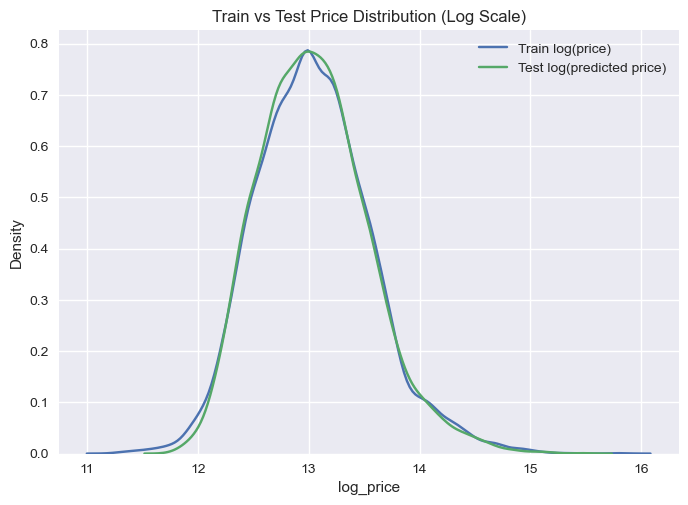

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Train log-prices
sns.kdeplot(train_df["log_price"], label="Train log(price)")

# Test predictions in log-space
sns.kdeplot(np.log1p(submission["predicted_price"]), label="Test log(predicted price)")

plt.legend()
plt.title("Train vs Test Price Distribution (Log Scale)")
plt.show()
